# Урок 15.21. Теория игр: стратегии, равновесия, Шепли

**Интерактивная версия:** `lessons/lesson_15_21/web/index.html`

Каждое утверждение урока проверяем кодом: равновесия — перебором и уравнениями безразличия, игры с нулевой
суммой — линейным программированием `scipy`, обучение в играх — симуляцией, значения Шепли — перебором порядков
и коалиций, SHAP — сверкой с библиотекой `shap` и TreeSHAP scikit-learn, AdaBoost — учебной библиотекой `gbcourse`.

1. Язык игр: доминирование, удаление доминируемых стратегий, «угадай 2/3», равновесия Нэша, случайные игры,
   Браес и Пигу, Курно.
2. Смешанные стратегии: пенальти, принцип безразличия, коррелированное равновесие (ЛП), перебор носителей.
3. Нулевая сумма: седло, графический метод, симплекс через `linprog`, фиктивная игра, минимаксная оценка.
4. Обучение в играх: сожаление FTL и Hedge, самоигра, сопоставление сожалений, репликаторная динамика, GDA.
5. Последовательные игры: обратная индукция, ним, альфа-бета, торг, мрачный триггер, турнир Аксельрода.
6. Кооперативные игры: ядро, значение Шепли, индексы власти, аксиомы, выборка порядков.
7. Теория игр в ML: SHAP против `shap`, TreeSHAP бустинга, AdaBoost как игра, аукционы, стратегическая
   классификация.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math
from fractions import Fraction as F
from functools import lru_cache
from itertools import combinations, permutations, product

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import linprog

from gbcourse import AdaBoost, GBRegressor, datasets, explain
from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, INK, MUTED, ORANGE, RED, SERIES

use_course_style()

## 1. Язык игр

### Доминирование и последовательное удаление
Функция `iesds` вычёркивает строго (или слабо) доминируемые стратегии по одной, сначала у игрока 1.

In [2]:
def dominates(u, w, weak=False):
    u, w = np.asarray(u, float), np.asarray(w, float)
    return (u > w).all() or (weak and (u >= w).all() and (u > w).any())


def iesds(A, B, weak=False):
    A, B = np.asarray(A, float), np.asarray(B, float)
    R, C, log = list(range(A.shape[0])), list(range(A.shape[1])), []
    while True:
        r = next((b for b in R for a in R if a != b and dominates(A[a, C], A[b, C], weak)), None)
        if r is not None:
            R.remove(r)
            log.append(("1", r))
            continue
        c = next((b for b in C for a in C if a != b and dominates(B[R, a], B[R, b], weak)), None)
        if c is not None:
            C.remove(c)
            log.append(("2", c))
            continue
        return R, C, log


A = [[3, 0, 0.5], [2, 1, 1], [1, 0, 0]]
B = [[1, 2, 0], [0, 1, 2], [3, 2, 1]]
R, C, log = iesds(A, B)
print("игра 3×3: шаги", log, "→ остаётся", R, C)
assert (R, C) == ([1], [2]) and len(log) == 4


def hotelling(n):
    share = lambda i, j: sum(1 if abs(x - i) < abs(x - j) else 0.5 if abs(x - i) == abs(x - j) else 0 for x in range(n))
    A = np.array([[share(i, j) for j in range(n)] for i in range(n)])
    return A, A.T.copy()


for n in (5, 7, 10, 11):
    R, C, _ = iesds(*hotelling(n))
    print(f"пляж из {n} мест: остаются места {[r + 1 for r in R]}")
assert iesds(*hotelling(7))[0] == [3]

price = np.array([[30, 0, 0], [40, 20, 0], [20, 20, 10]])
print("цены 10/8/6, строгое удаление:", iesds(price, price.T)[:2], " слабое:", iesds(price, price.T, weak=True)[:2])
assert iesds(price, price.T, weak=True)[:2] == ([2], [2])

игра 3×3: шаги [('1', 2), ('2', 0), ('1', 0), ('2', 1)] → остаётся [1] [2]
пляж из 5 мест: остаются места [3]
пляж из 7 мест: остаются места [4]
пляж из 10 мест: остаются места [5, 6]
пляж из 11 мест: остаются места [6]
цены 10/8/6, строгое удаление: ([0, 1, 2], [0, 1, 2])  слабое: ([2], [2])


### «Угадай 2/3 среднего»: уровни рассуждения и доминирование

In [3]:
p = 2 / 3
print("уровни 1–4:", [round(50 * p**k, 2) for k in range(1, 5)])
print("после k шагов удаления — числа до:", [round(100 * p**k, 2) for k in range(1, 6)])

уровни 1–4: [33.33, 22.22, 14.81, 9.88]
после k шагов удаления — числа до: [66.67, 44.44, 29.63, 19.75, 13.17]


### Равновесия Нэша и случайные игры
Среднее число чистых равновесий в случайной игре n×n равно 1 при любом n, а доля игр хотя бы с одним равновесием
убывает от 7/8 к 1 − 1/e. Генератор курса даёт те же 1000 игр, что и виджет шага 5.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


n =  2: доля игр с равновесием 0.871, среднее число 0.999
n =  3: доля игр с равновесием 0.796, среднее число 1.026
n =  4: доля игр с равновесием 0.745, среднее число 0.980
n =  5: доля игр с равновесием 0.726, среднее число 1.028
n =  6: доля игр с равновесием 0.701, среднее число 0.992
n =  7: доля игр с равновесием 0.691, среднее число 1.024
n =  8: доля игр с равновесием 0.657, среднее число 0.942
n =  9: доля игр с равновесием 0.650, среднее число 0.962
n = 10: доля игр с равновесием 0.664, среднее число 1.023


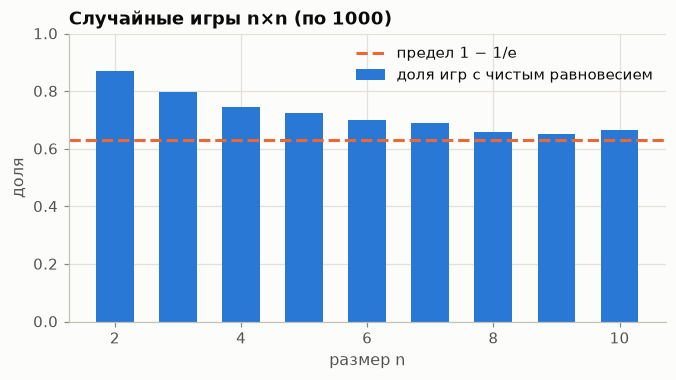

In [4]:
def pure_ne(A, B):
    A, B = np.asarray(A), np.asarray(B)
    return [(i, j) for i in range(A.shape[0]) for j in range(A.shape[1]) if A[i, j] == A[:, j].max() and B[i, j] == B[i, :].max()]


stat = []
for n in range(2, 11):
    rng = Mulberry32(2026 + n)
    has = tot = 0
    for _ in range(1000):
        A = [[rng.random() for _ in range(n)] for _ in range(n)]
        Bm = [[rng.random() for _ in range(n)] for _ in range(n)]
        c = len(pure_ne(A, Bm))
        has, tot = has + (c > 0), tot + c
    stat.append((n, has / 1000, tot / 1000))
for n, share, mean in stat:
    print(f"n = {n:2}: доля игр с равновесием {share:.3f}, среднее число {mean:.3f}")
assert abs(stat[0][1] - 7 / 8) < 0.03 and all(abs(m - 1) < 0.1 for _, _, m in stat)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar([s[0] for s in stat], [s[1] for s in stat], color=BLUE, width=0.6, label="доля игр с чистым равновесием")
ax.axhline(1 - 1 / math.e, color=ORANGE, ls="--", label="предел 1 − 1/e")
ax.set(xlabel="размер n", ylabel="доля", ylim=(0, 1), title="Случайные игры n×n (по 1000)")
ax.legend()
plt.show()

### Парадокс Браеса и цена анархии Пигу

In [5]:
def braess_eq(N, shortcut):
    if not shortcut or N >= 9000:
        return N / 200 + 45
    return N / 50 if N <= 4500 else 90.0


def braess_opt(N):
    x = np.arange(0, N / 2 + 1)
    cost = 2 * (N - x) ** 2 / 100 + 90 * x
    return cost.min() / N


print("N = 4000: без перемычки", braess_eq(4000, False), " с перемычкой", braess_eq(4000, True), " оптимум", round(braess_opt(4000), 2))
assert braess_eq(4000, False) == 65 and braess_eq(4000, True) == 80 and abs(braess_opt(4000) - 64.69) < 0.01
for d in (1, 2, 10):
    x = (d + 1) ** (-1 / d)
    print(f"Пигу, d = {d}: цена анархии {1 / (x ** (d + 1) + 1 - x):.4f}")

N = 4000: без перемычки 65.0  с перемычкой 80.0  оптимум 64.69
Пигу, d = 1: цена анархии 1.3333
Пигу, d = 2: цена анархии 1.6258
Пигу, d = 10: цена анархии 3.5121


### Дуополия Курно: ответы по очереди сходятся к равновесию

In [6]:
a, c = 100, 10
br = lambda q: max(0.0, (a - c - q) / 2)
q1, q2, path = 5.0, 75.0, []
for _ in range(8):
    q1 = br(q2)
    q2 = br(q1)
    path.append((q1, q2))
print("ответы по очереди:", [tuple(round(v, 3) for v in pq) for pq in path[-3:]])
qm = (a - c) / 4
qd = br(qm)
print("равновесие 30 × 30, прибыль", (a - 60 - c) * 30, "; сговор", (a - 2 * qm - c) * qm, "; нарушитель", (a - qd - qm - c) * qd)
assert abs(path[-1][0] - 30) < 0.01 and abs((a - qd - qm - c) * qd - 1139.0625) < 1e-9

ответы по очереди: [(29.978, 30.011), (29.995, 30.003), (29.999, 30.001)]
равновесие 30 × 30, прибыль 900 ; сговор 1012.5 ; нарушитель 1139.0625


## 2. Смешанные стратегии

### Пенальти и принцип безразличия

In [7]:
M = np.array([[0.583, 0.9497], [0.9291, 0.6992]])
den = M[0, 0] - M[0, 1] - M[1, 0] + M[1, 1]
p_star, q_star = (M[1, 1] - M[1, 0]) / den, (M[1, 1] - M[0, 1]) / den
v = p_star * M[0, 0] + (1 - p_star) * M[1, 0]
print(f"пенальти: p* = {p_star:.4f}, q* = {q_star:.4f}, v = {v:.4f}")
assert abs(p_star - 0.385) < 1e-3 and abs(v - 0.7957) < 1e-3


def mixed2(A, B):
    A, B = np.asarray(A, dtype=object), np.asarray(B, dtype=object)
    p = F(B[1, 1] - B[1, 0], B[0, 0] - B[1, 0] - B[0, 1] + B[1, 1])
    q = F(A[1, 1] - A[0, 1], A[0, 0] - A[0, 1] - A[1, 0] + A[1, 1])
    return p, q


print("встреча:", mixed2([[2, 0], [0, 1]], [[1, 0], [0, 2]]), " с бонусом +2:", mixed2([[4, 0], [0, 1]], [[1, 0], [0, 2]]))
assert mixed2([[4, 0], [0, 1]], [[1, 0], [0, 2]]) == (F(2, 3), F(1, 5))

пенальти: p* = 0.3854, q* = 0.4199, v = 0.7957
встреча: (Fraction(2, 3), Fraction(1, 3))  с бонусом +2: (Fraction(2, 3), Fraction(1, 5))


### Коррелированное равновесие — линейная программа
Игра «слабак»: максимизируем сумму выигрышей при условиях послушания.

In [8]:
A = np.array([[0, 7], [2, 6]])
Bc = A.T
G = np.array([[A[0, 0] - A[1, 0], A[0, 1] - A[1, 1], 0, 0], [0, 0, A[1, 0] - A[0, 0], A[1, 1] - A[0, 1]],
              [Bc[0, 0] - Bc[0, 1], 0, Bc[1, 0] - Bc[1, 1], 0], [0, Bc[0, 1] - Bc[0, 0], 0, Bc[1, 1] - Bc[1, 0]]])
res = linprog(-(A + Bc).ravel(), A_ub=-G, b_ub=np.zeros(4), A_eq=[np.ones(4)], b_eq=[1], bounds=[(0, 1)] * 4)
print("лучшее коррелированное равновесие:", res.x.round(4), " каждому", -res.fun / 2)
print("смешанное Нэша: каждому", float(F(14, 3)))
assert np.allclose(res.x, [0, 0.25, 0.25, 0.5]) and abs(-res.fun / 2 - 5.25) < 1e-9

лучшее коррелированное равновесие: [0.   0.25 0.25 0.5 ]  каждому 5.25
смешанное Нэша: каждому 4.666666666666667


### Перебор носителей

In [9]:
def support_enum(A, B):
    A, B = np.asarray(A, float), np.asarray(B, float)
    m, n = A.shape
    found = []
    for k in range(1, min(m, n) + 1):
        for rows_ in combinations(range(m), k):
            for J in combinations(range(n), k):
                Mq = np.block([[A[np.ix_(rows_, J)], -np.ones((k, 1))], [np.ones((1, k)), np.zeros((1, 1))]])
                Mp = np.block([[B[np.ix_(rows_, J)].T, -np.ones((k, 1))], [np.ones((1, k)), np.zeros((1, 1))]])
                rhs = np.r_[np.zeros(k), 1]
                try:
                    sq, sp = np.linalg.solve(Mq, rhs), np.linalg.solve(Mp, rhs)
                except np.linalg.LinAlgError:
                    continue
                q, p = np.zeros(n), np.zeros(m)
                q[list(J)], p[list(rows_)] = sq[:k], sp[:k]
                if (q < -1e-9).any() or (p < -1e-9).any() or (A @ q > sq[k] + 1e-9).any() or (p @ B > sp[k] + 1e-9).any():
                    continue
                if not any(np.allclose(p, a) and np.allclose(q, b) for a, b in found):
                    found.append((p, q))
    return found


rps2 = np.array([[0, -1, 2], [1, 0, -1], [-2, 1, 0]])
print("КНБ вдвойне:", [(p.round(3), q.round(3)) for p, q in support_enum(rps2, -rps2)])
coord = np.diag([3, 2, 1])
eqs = support_enum(coord, coord)
print("координация 3×3: равновесий", len(eqs), "; полностью смешанное:", [p.round(4) for p, q in eqs if (p > 0).all()])
assert len(eqs) == 7

КНБ вдвойне: [(array([0.25, 0.5 , 0.25]), array([0.25, 0.5 , 0.25]))]
координация 3×3: равновесий 7 ; полностью смешанное: [array([0.1818, 0.2727, 0.5455])]


## 3. Игры с нулевой суммой

Решатель через `linprog`: стратегия игрока 1 и (двойственная) стратегия игрока 2.

In [10]:
def solve_zero_sum(M):
    M = np.asarray(M, float)
    m, n = M.shape
    r1 = linprog(np.r_[np.zeros(m), -1], A_ub=np.c_[-M.T, np.ones(n)], b_ub=np.zeros(n),
                 A_eq=[np.r_[np.ones(m), 0]], b_eq=[1], bounds=[(0, None)] * m + [(None, None)])
    r2 = linprog(np.r_[np.zeros(n), 1], A_ub=np.c_[M, -np.ones(m)], b_ub=np.zeros(m),
                 A_eq=[np.r_[np.ones(n), 0]], b_eq=[1], bounds=[(0, None)] * n + [(None, None)])
    return r1.x[:m], r2.x[:n], r1.x[-1]


def blotto(sa, sb, k=3):
    alloc = lambda s: [c for c in product(range(s + 1), repeat=k) if sum(c) == s]
    RA, RB = alloc(sa), alloc(sb)
    return np.array([[np.sign(np.array(x) - np.array(y)).sum() for y in RB] for x in RA]), RA


games = {"игра A": [[3, -1, 2], [-2, 2, 1]], "игра D": [[1, 4, -1, 2], [3, -2, 2, 0]], "прятки": np.diag([0.9, 0.6, 0.3]),
         "КНБ вдвойне": rps2, "Блотто 4×4": blotto(4, 4)[0]}
for name, M in games.items():
    p, q, v = solve_zero_sum(M)
    print(f"{name:12}: v = {v:.4f}, p* = {p.round(3)}" + (f", q* = {q.round(3)}" if len(q) <= 5 else ""))
assert abs(solve_zero_sum(games["прятки"])[2] - 9 / 55) < 1e-9
assert abs(solve_zero_sum(games["игра A"])[2] - 0.5) < 1e-9

M = np.array([[3, -1, 2], [-2, 2, 1]])
print("седло: максимин", M.min(1).max(), " минимакс", M.max(0).min(), " — нет седла, цена 1/2 между ними")

игра A      : v = 0.5000, p* = [0.5 0.5], q* = [0.375 0.625 0.   ]
игра D      : v = 0.6667, p* = [0.444 0.556], q* = [0.    0.333 0.667 0.   ]
прятки      : v = 0.1636, p* = [0.182 0.273 0.545], q* = [0.182 0.273 0.545]
КНБ вдвойне : v = -0.0000, p* = [0.25 0.5  0.25], q* = [0.25 0.5  0.25]
Блотто 4×4  : v = -0.0000, p* = [ 0.    -0.     0.333  0.     0.     0.     0.     0.     0.     0.333
 -0.     0.333  0.    -0.     0.   ]
седло: максимин -1  минимакс 2  — нет седла, цена 1/2 между ними


### Графический метод: нижняя огибающая и теорема о минимаксе

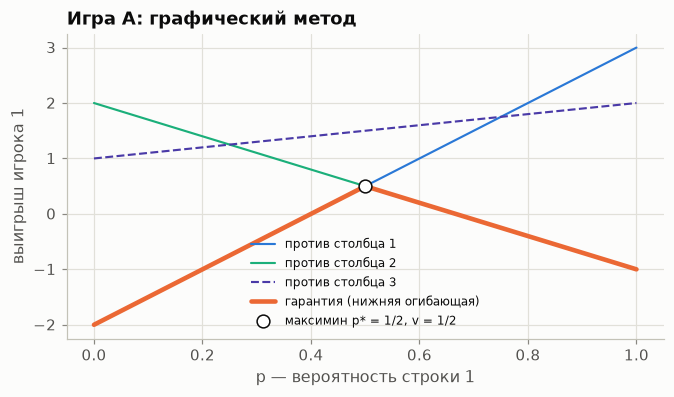

In [11]:
ps = np.linspace(0, 1, 201)
lines = np.outer(ps, M[0]) + np.outer(1 - ps, M[1])
fig, ax = plt.subplots(figsize=(7, 3.6))
for j in range(3):
    ax.plot(ps, lines[:, j], color=SERIES[[0, 2, 6][j]], lw=1.4, ls="-" if j < 2 else "--", label=f"против столбца {j + 1}")
ax.plot(ps, lines.min(1), color=ORANGE, lw=3, label="гарантия (нижняя огибающая)")
ax.scatter([0.5], [0.5], s=70, facecolor="white", edgecolor=INK, zorder=5, label="максимин p* = 1/2, v = 1/2")
ax.set(xlabel="p — вероятность строки 1", ylabel="выигрыш игрока 1", title="Игра A: графический метод")
ax.legend(fontsize=8)
plt.show()

### Фиктивная игра Брауна — Робинсон

In [12]:
def fictitious(M, T):
    M = np.asarray(M, float)
    c1, c2, i, j = np.zeros(M.shape[0]), np.zeros(M.shape[1]), 0, 0
    lo, hi = [], []
    for t in range(1, T + 1):
        c1[i] += 1
        c2[j] += 1
        lo.append((c1 @ M).min() / t)
        hi.append((M @ c2).max() / t)
        i, j = int(np.argmax(M @ c2)), int(np.argmin(c1 @ M))
    return np.array(lo), np.array(hi), c1 / T


lo, hi, freq = fictitious(np.diag([0.9, 0.6, 0.3]), 5000)
print(f"прятки, 5000 раундов: {lo[-1]:.4f} ≤ v = {9 / 55:.4f} ≤ {hi[-1]:.4f}; частоты {freq.round(3)}")
assert lo[-1] <= 9 / 55 <= hi[-1]

прятки, 5000 раундов: 0.1604 ≤ v = 0.1636 ≤ 0.1672; частоты [0.18  0.267 0.553]


### Игра с природой: минимаксная оценка вероятности

In [13]:
n = 10
pp = np.linspace(0, 1, 100001)
risk = lambda a: (n * pp * (1 - pp) + a**2 * (1 - 2 * pp) ** 2) / (n + 2 * a) ** 2
for name, a in [("X/n", 0), ("Лаплас a = 1", 1), ("минимаксная a = √n/2", np.sqrt(n) / 2)]:
    r = risk(a)
    print(f"{name:22}: худший риск {r.max():.5f}, средний {r.mean():.5f}")
assert np.ptp(risk(np.sqrt(n) / 2)) < 1e-15

X/n                   : худший риск 0.02500, средний 0.01667
Лаплас a = 1          : худший риск 0.01736, средний 0.01389
минимаксная a = √n/2  : худший риск 0.01443, средний 0.01443


## 4. Обучение в играх

### Сожаление: FTL против Hedge на враждебной последовательности

In [14]:
T = 200
adv = np.array([[0.5, 0]] + [[0, 1] if t % 2 else [1, 0] for t in range(1, T)])


def regret(losses, algo, eta=None):
    cum, total = np.zeros(losses.shape[1]), 0.0
    for loss in losses:
        if algo == "ftl":
            pvec = np.eye(len(cum))[np.argmin(cum)]
        else:
            w = np.exp(-eta * (cum - cum.min()))
            pvec = w / w.sum()
        total += pvec @ loss
        cum += loss
    return total - cum.min()


r_ftl, r_hedge = regret(adv, "ftl"), regret(adv, "hedge", np.sqrt(8 * np.log(2) / T))
print(f"FTL: {r_ftl}, Hedge: {r_hedge:.2f}, гарантия √(T ln 2 / 2) = {np.sqrt(T * np.log(2) / 2):.2f}")
assert r_ftl == 100 and r_hedge <= np.sqrt(T * np.log(2) / 2)

FTL: 100.0, Hedge: 4.39, гарантия √(T ln 2 / 2) = 8.33


### Hedge с экспертами: зависимость сожаления от темпа

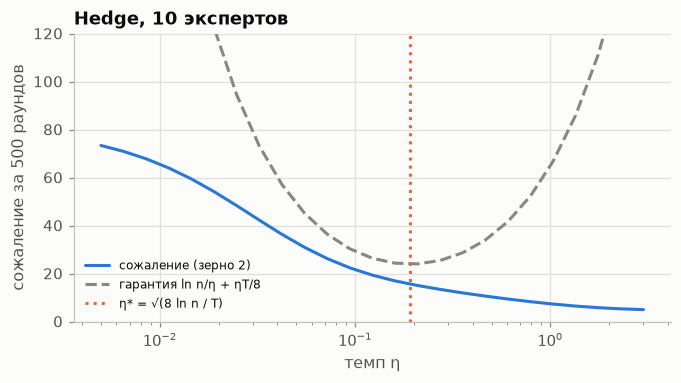

на случайных независимых потерях большой темп не вредит: 73.4 → 5.0


In [15]:
def hedge_experts(n, eta, seed, T=500):
    rng = Mulberry32(seed)
    rate = [0.3 + 0.4 * i / (n - 1) for i in range(n)]
    cum, alg = np.zeros(n), 0.0
    for _ in range(T):
        w = np.exp(-eta * (cum - cum.min()))
        loss = np.array([float(rng.random() < r) for r in rate])
        alg += (w / w.sum()) @ loss
        cum += loss
    return alg - cum.min()


etas = np.geomspace(0.005, 3, 25)
regs = [hedge_experts(10, e, 2) for e in etas]
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(etas, regs, color=BLUE, lw=2, label="сожаление (зерно 2)")
ax.plot(etas, np.log(10) / etas + etas * 500 / 8, color=MUTED, ls="--", label="гарантия ln n/η + ηT/8")
ax.axvline(np.sqrt(8 * np.log(10) / 500), color=ORANGE, ls=":", label="η* = √(8 ln n / T)")
ax.set(xscale="log", ylim=(0, 120), xlabel="темп η", ylabel="сожаление за 500 раундов", title="Hedge, 10 экспертов")
ax.legend(fontsize=8)
plt.show()
print("на случайных независимых потерях большой темп не вредит:", round(regs[0], 1), "→", round(regs[-1], 1))

### Самоигра: средние стратегии сходятся, последние — нет (и оптимистичный Hedge)

In [16]:
R3 = np.array([[0, -1, 1], [1, 0, -1], [-1, 1, 0]])
exploit = lambda M, p, q: (M @ q).max() - (p @ M).min()


def self_play(eta, T, optimistic=False):
    L1, L2 = np.log([0.6, 0.25, 0.15]), np.log([0.2, 0.5, 0.3])
    u1p, u2p, a1, a2 = np.zeros(3), np.zeros(3), np.zeros(3), np.zeros(3)
    for _ in range(T):
        p1, p2 = np.exp(L1) / np.exp(L1).sum(), np.exp(L2) / np.exp(L2).sum()
        u1, u2 = R3 @ p2, -(p1 @ R3)
        a1, a2 = a1 + p1, a2 + p2
        k = 2 if optimistic else 1
        L1, L2 = L1 + eta * (k * u1 - (k - 1) * u1p), L2 + eta * (k * u2 - (k - 1) * u2p)
        u1p, u2p = u1, u2
    return exploit(R3, p1, p2), exploit(R3, a1 / T, a2 / T)


last, avg = self_play(0.1, 600)
last_o1, _ = self_play(0.1, 600, optimistic=True)
last_o, _ = self_play(0.3, 600, optimistic=True)
print(f"Hedge: уязвимость последних {last:.3f}, средних {avg:.3f}")
print(f"оптимистичный Hedge, последние стратегии: η = 0.1 → {last_o1:.3f} (медленно), η = 0.3 → {last_o:.5f}")
assert avg < 0.05 < last and last_o < 0.01

Hedge: уязвимость последних 1.451, средних 0.040
оптимистичный Hedge, последние стратегии: η = 0.1 → 0.264 (медленно), η = 0.3 → 0.00007


### Сопоставление сожалений (и «плюс») на игре Блотто

In [17]:
def regret_matching(M, T, plus):
    M = np.asarray(M, float)
    m, n = M.shape
    R1, R2 = np.zeros(m), np.zeros(n)
    x, y = np.arange(1, m + 1) / (m * (m + 1) / 2), np.arange(n, 0, -1) / (n * (n + 1) / 2)
    s1, s2, W = np.zeros(m), np.zeros(n), 0.0
    pos = lambda R: np.maximum(R, 0) / np.maximum(R, 0).sum() if np.maximum(R, 0).sum() > 0 else np.ones(len(R)) / len(R)
    for t in range(1, T + 1):
        u1, u2 = M @ y, -(x @ M)
        w = t if plus else 1
        s1, s2, W = s1 + w * x, s2 + w * y, W + w
        R1, R2 = R1 + u1 - x @ u1, R2 + u2 - y @ u2
        if plus:
            R1, R2 = np.maximum(R1, 0), np.maximum(R2, 0)
        x, y = pos(R1), pos(R2)
    return exploit(M, s1 / W, s2 / W)


Mb = blotto(4, 4)[0]
print("Блотто: уязвимость после 2000 раундов — RM", round(regret_matching(Mb, 2000, False), 4), ", RM+", round(regret_matching(Mb, 2000, True), 4))

Блотто: уязвимость после 2000 раундов — RM 0.0308 , RM+ 0.0118


### Репликаторная динамика: КНБ с выигрышем ε за ничью

ε = -0.2: доли через t = 60: [0.33  0.334 0.336]
ε = +0.0: доли через t = 60: [0.243 0.519 0.238]
ε = +0.2: доли через t = 60: [0.947 0.053 0.   ]


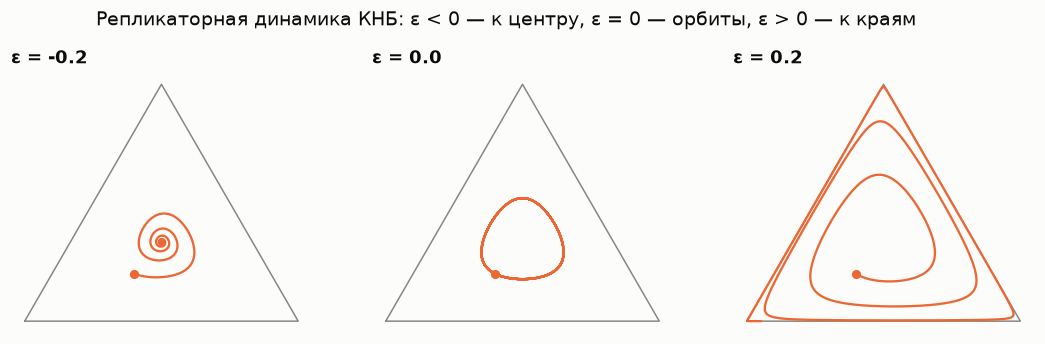

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, eps in zip(axes, [-0.2, 0.0, 0.2]):
    A = R3 + eps * np.eye(3)
    sol = solve_ivp(lambda t, x, A=A: x * (A @ x - x @ A @ x), (0, 60), [0.5, 0.3, 0.2], rtol=1e-9, atol=1e-12, dense_output=True)
    X = sol.sol(np.linspace(0, 60, 3000))
    tx, ty = X[1] + X[2] / 2, X[2] * np.sqrt(3) / 2
    ax.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3) / 2, 0], color=MUTED, lw=1)
    ax.plot(tx, ty, color=ORANGE, lw=1.5)
    ax.scatter([tx[0]], [ty[0]], color=ORANGE, zorder=3)
    ax.set(title=f"ε = {eps}", aspect="equal")
    ax.axis("off")
    print(f"ε = {eps:+.1f}: доли через t = 60: {X[:, -1].round(3)}")
fig.suptitle("Репликаторная динамика КНБ: ε < 0 — к центру, ε = 0 — орбиты, ε > 0 — к краям")
plt.show()

### Градиентный спуск-подъём на f(x, y) = xy

In [19]:
def gda(method, eta=0.2, K=60, z=(1.5, 1.0)):
    x, y = z
    px, py = y, x
    for _ in range(K):
        if method == "одновременный":
            x, y = x - eta * y, y + eta * x
        elif method == "поочерёдный":
            x = x - eta * y
            y = y + eta * x
        elif method == "экстраградиент":
            xh, yh = x - eta * y, y + eta * x
            x, y = x - eta * yh, y + eta * xh
        else:
            cx, cy = y, x
            x, y = x - eta * (2 * cx - px), y + eta * (2 * cy - py)
            px, py = cx, cy
    return np.hypot(x, y)


for mth in ["одновременный", "поочерёдный", "экстраградиент", "оптимистичный"]:
    print(f"{mth:15}: {gda(mth):.4f}")
assert abs(gda("одновременный") - np.hypot(1.5, 1) * 1.04**30) < 1e-9

одновременный  : 5.8471
поочерёдный    : 1.7299
экстраградиент : 0.5569
оптимистичный  : 0.5245


## 5. Последовательные и повторяющиеся игры

### Обратная индукция и ним

In [20]:
def solve_tree(node):
    if not isinstance(node[1], dict):
        return node, []
    player, moves = node
    best = max(((solve_tree(ch), a) for a, ch in moves.items()), key=lambda r: r[0][0][player])
    (pay, path), action = best
    return pay, [action] + path


entry = (0, {"не входить": (0, 10), "войти": (1, {"война": (-2, 2), "поделить": (3, 5)})})
print("вход на рынок:", solve_tree(entry))
cent_pays = [(1, 0), (0, 2), (3, 1), (2, 4), (5, 3), (4, 6)]
node = (6, 5)
for k in range(5, -1, -1):
    node = (k % 2, {"взять": cent_pays[k], "передать": node})
print("сороконожка:", solve_tree(node))
assert solve_tree(node)[0] == (1, 0)


@lru_cache(None)
def nim_win(state):
    return any(not nim_win(tuple(sorted(state[:i] + (v,) + state[i + 1:]))) for i, h in enumerate(state) for v in range(h))


assert all(nim_win(tuple(sorted(s))) == ((s[0] ^ s[1] ^ s[2]) != 0) for s in product(range(8), repeat=3))
print("ним: позиция выигрышна ⇔ XOR ≠ 0 — проверено перебором для кучек до 7")

вход на рынок: ((3, 5), ['войти', 'поделить'])
сороконожка: ((1, 0), ['взять'])
ним: позиция выигрышна ⇔ XOR ≠ 0 — проверено перебором для кучек до 7


### Альфа-бета: сколько листьев экономит идеальный порядок

In [21]:
def alphabeta_count(leaves, b, d, order):
    count = [0]

    def exact(lo, depth, mx):
        if depth == d:
            return leaves[lo]
        span = b ** (d - depth - 1)
        vals = [exact(lo + k * span, depth + 1, not mx) for k in range(b)]
        return max(vals) if mx else min(vals)

    def go(lo, depth, alpha, beta, mx):
        if depth == d:
            count[0] += 1
            return leaves[lo]
        span = b ** (d - depth - 1)
        kids = list(range(b))
        if order:
            kids.sort(key=lambda k: exact(lo + k * span, depth + 1, not mx), reverse=mx)
        best = -np.inf if mx else np.inf
        for k in kids:
            v = go(lo + k * span, depth + 1, alpha, beta, not mx)
            if mx:
                best, alpha = max(best, v), max(alpha, v)
            else:
                best, beta = min(best, v), min(beta, v)
            if alpha >= beta:
                break
        return best

    v = go(0, 0, -np.inf, np.inf, True)
    return v, count[0], exact(0, 0, True)


for d in (4, 6):
    rnd, best = [], []
    for t in range(30):
        rng = Mulberry32(1000 + t)
        lv = [rng.randint(19) - 9 for _ in range(3**d)]
        v1, c1, ex1 = alphabeta_count(lv, 3, d, False)
        v2, c2, _ = alphabeta_count(lv, 3, d, True)
        assert v1 == v2 == ex1
        rnd.append(c1)
        best.append(c2)
    print(f"d = {d}: всего {3**d}, альфа-бета {np.mean(rnd):.0f}, идеальный порядок {np.mean(best):.0f} (формула {3**math.ceil(d / 2) + 3**(d // 2) - 1})")

d = 4: всего 81, альфа-бета 42, идеальный порядок 17 (формула 17)
d = 6: всего 729, альфа-бета 213, идеальный порядок 53 (формула 53)


### Торг Рубинштейна и мрачный триггер

In [22]:
def rubinstein(d1, d2, T):
    share = 1.0
    for k in range(2, T + 1):
        share = 1 - (d2 if (T - k) % 2 == 0 else d1) * share
    return share


print("Рубинштейн 0.9/0.8: T = 6 →", round(rubinstein(0.9, 0.8, 6), 4), ", T = 61 →", round(rubinstein(0.9, 0.8, 61), 4), ", формула", round(0.2 / 0.28, 4))
assert abs(rubinstein(0.9, 0.8, 61) - 0.2 / 0.28) < 1e-3
T_, R_, P_ = 5, 3, 1
print("мрачный триггер: δ* =", (T_ - R_) / (T_ - P_))

Рубинштейн 0.9/0.8: T = 6 →

 0.4477 , T = 61 → 0.7143 , формула 0.7143
мрачный триггер: δ* = 0.5


### Турнир Аксельрода (тот же код, что у виджета шага 32)

In [23]:
PAY = [[3, 0], [5, 1]]
STRATS = {
    "всегда сотрудничать": lambda me, op, rng: 0,
    "всегда предавать": lambda me, op, rng: 1,
    "око за око": lambda me, op, rng: op[-1] if op else 0,
    "подозрительное око за око": lambda me, op, rng: op[-1] if op else 1,
    "око за два ока": lambda me, op, rng: 1 if len(op) >= 2 and op[-1] and op[-2] else 0,
    "мрачный триггер": lambda me, op, rng: 1 if 1 in op else 0,
    "Павлов": lambda me, op, rng: (0 if me[-1] == op[-1] else 1) if me else 0,
    "щедрое око за око": lambda me, op, rng: (0 if rng.random() < 1 / 3 else 1) if op and op[-1] else 0,
    "случайно": lambda me, op, rng: 0 if rng.random() < 0.5 else 1,
}
names, fs = list(STRATS), list(STRATS.values())


def tournament(noise, rounds=200, seed=1):
    n = len(fs)
    W = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            rng = Mulberry32(1000 * seed + 37 * i + j)
            a, b, sa, sb = [], [], 0, 0
            for _ in range(rounds):
                x, y = fs[i](a, b, rng), fs[j](b, a, rng)
                if noise > 0:
                    if rng.random() < noise:
                        x = 1 - x
                    if rng.random() < noise:
                        y = 1 - y
                a.append(x)
                b.append(y)
                sa += PAY[x][y]
                sb += PAY[y][x]
            W[i, j], W[j, i] = sa / rounds, sb / rounds
    return W


for noise in (0.0, 0.05):
    W = tournament(noise)
    order = np.argsort(-W.mean(1))
    print(f"шум {noise:.0%}: " + ", ".join(f"{names[k]} {W[k].mean():.3f}" for k in order[:3]) + f" … последний: {names[order[-1]]}")
W0 = tournament(0.0)
assert abs(W0[2].mean() - 2.647) < 1e-3 and names[np.argmin(W0.mean(1))] == "всегда предавать"

шум 0%: око за два ока 2.649, око за око 2.647, щедрое око за око 2.628 … последний: всегда предавать
шум 5%: щедрое око за око 2.294, Павлов 2.280, подозрительное око за око 2.257 … последний: всегда сотрудничать


## 6. Кооперативные игры и значение Шепли

In [24]:
def shapley(v, n):
    phi = [F(0)] * n
    for order in permutations(range(n)):
        S = set()
        for j in order:
            phi[j] += F(v(S | {j}) - v(S), math.factorial(n))
            S.add(j)
    return phi


games = {
    "перчатки": lambda S: 1 if 0 in S and (1 in S or 2 in S) else 0,
    "аэропорт": lambda S: max([0] + [[1, 2, 3][i] for i in S]),
    "такси": lambda S: max([0] + [[6, 10, 15][i] for i in S]),
    "модель 2x₁ + x₂ + x₁x₂": lambda S: 2 * (0 in S) + (1 in S) + (0 in S) * (1 in S),
}
for name, v in games.items():
    print(f"{name:24}: {[str(x) for x in shapley(v, 3)]}")
assert shapley(games["такси"], 3) == [2, 4, 9]


def voting_power(w, q):
    n = len(w)
    ss, bz = [F(0)] * n, [0] * n
    for j in range(n):
        others = [i for i in range(n) if i != j]
        for k in range(n):
            for S in combinations(others, k):
                s = sum(w[i] for i in S)
                if s < q <= s + w[j]:
                    ss[j] += F(math.factorial(k) * math.factorial(n - k - 1), math.factorial(n))
                    bz[j] += 1
    return ss, [b / sum(bz) for b in bz]


for name, w, q in [("[51; 49, 49, 2]", [49, 49, 2], 51), ("ЕЭС 1958", [4, 4, 4, 2, 2, 1], 12), ("[4; 3, 2, 1, 1]", [3, 2, 1, 1], 4)]:
    ss, bz = voting_power(w, q)
    print(f"{name:16}: Шепли — Шубик {[str(x) for x in ss]}, Банцаф {np.round(bz, 3)}")
ss_un, _ = voting_power([7] * 5 + [1] * 10, 39)
print(f"Совбез ООН: постоянный {float(ss_un[0]):.4f}, непостоянный {float(ss_un[5]):.5f}, отношение {float(ss_un[0] / ss_un[5]):.1f}")
assert voting_power([4, 4, 4, 2, 2, 1], 12)[0][5] == 0

перчатки                : ['2/3', '1/6', '1/6']
аэропорт                : ['1/3', '5/6', '11/6']
такси                   : ['2', '4', '9']
модель 2x₁ + x₂ + x₁x₂  : ['5/2', '3/2', '0']
[51; 49, 49, 2] : Шепли — Шубик ['1/3', '1/3', '1/3'], Банцаф [0.333 0.333 0.333]
ЕЭС 1958        : Шепли — Шубик ['7/30', '7/30', '7/30', '3/20', '3/20', '0'], Банцаф [0.238 0.238 0.238 0.143 0.143 0.   ]
[4; 3, 2, 1, 1] : Шепли — Шубик ['1/2', '1/6', '1/6', '1/6'], Банцаф [0.5   0.167 0.167 0.167]


Совбез ООН: постоянный 0.1963, непостоянный 0.00186, отношение 105.2


### Ядро игры трёх лиц и аксиома аддитивности

In [25]:
def in_core(x, v12, v13, v23):
    return x[0] + x[1] >= v12 - 1e-12 and x[0] + x[2] >= v13 - 1e-12 and x[1] + x[2] >= v23 - 1e-12


sav = lambda S: sum([6, 10, 15][i] for i in S) - max([0] + [[6, 10, 15][i] for i in S])
phi = shapley(sav, 3)
print("такси, экономия: Шепли", [str(x) for x in phi], " в ядре:", in_core(phi, 6, 6, 10))
print("перчатки: Шепли в ядре?", in_core(shapley(games["перчатки"], 3), 1, 1, 0))
vsum = lambda S: games["перчатки"](S) + games["модель 2x₁ + x₂ + x₁x₂"](S)
assert shapley(vsum, 3) == [a + b for a, b in zip(shapley(games["перчатки"], 3), shapley(games["модель 2x₁ + x₂ + x₁x₂"], 3))]
print("аддитивность значения Шепли проверена")

такси, экономия: Шепли ['4', '6', '6']  в ядре: True
перчатки: Шепли в ядре? False
аддитивность значения Шепли проверена


### Выборка порядков: ошибка ∝ 1/√K (и когда антитетические пары вредят)

In [26]:
w10, q10 = [12, 10, 9, 8, 6, 5, 3, 2, 1, 1], 29
exact = np.array([float(x) for x in voting_power(w10, q10)[0]])
v10 = lambda S: 1.0 if sum(w10[i] for i in S) >= q10 else 0.0


def estimate(K, anti, seed):
    rng = Mulberry32(seed)
    acc, cnt = np.zeros(10), 0
    for _ in range(K):
        order = rng.permutation(10)
        for o in ([order, order[::-1]] if anti else [order]):
            S, prev = [], 0.0
            for j in o:
                S.append(j)
                cur = v10(S)
                acc[j] += cur - prev
                prev = cur
            cnt += 1
    return acc / cnt


Ks = [10, 50, 200, 1000]
plain = [np.mean([np.abs(estimate(K, False, 100 + r) - exact).mean() for r in range(20)]) for K in Ks]
anti = [np.mean([np.abs(estimate(K // 2, True, 100 + r) - exact).mean() for r in range(20)]) for K in Ks]
for K, a_, b_ in zip(Ks, plain, anti):
    print(f"K = {K:5}: ошибка {a_:.4f}, антитетические {b_:.4f}")
assert plain[-1] < plain[0] / 5

K =    10: ошибка 0.0707, антитетические 0.0950
K =    50: ошибка 0.0316, антитетические 0.0444
K =   200: ошибка 0.0146, антитетические 0.0225
K =  1000: ошибка 0.0062, антитетические 0.0089


## 7. Теория игр в машинном обучении

### SHAP — значения Шепли «интервенционной» игры; сверка с библиотекой `shap`

In [27]:
rng = Mulberry32(38)
bg = []
for _ in range(200):
    a_, b_, c_ = rng.normal(), rng.normal(), rng.normal()
    bg.append([a_, 0.8 * a_ + 0.6 * b_, c_])
bg = np.array(bg)
x0 = np.array([1.5, 1.0, -0.5])
f = lambda X: X[:, 0] * X[:, 1] + X[:, 2]


def shap_exact(f, x, bg):
    n = len(x)

    def v(S):
        Z = bg.copy()
        Z[:, list(S)] = x[list(S)]
        return f(Z).mean()

    phi = np.zeros(n)
    for j in range(n):
        for k in range(n):
            for S in combinations([i for i in range(n) if i != j], k):
                phi[j] += math.factorial(k) * math.factorial(n - k - 1) / math.factorial(n) * (v(S + (j,)) - v(S))
    return v(()), phi


base, phi = shap_exact(f, x0, bg)
print("база", round(base, 4), " φ", phi.round(4), " база + Σφ =", round(base + phi.sum(), 6), " f(x) =", f(x0[None])[0])
base_m, phi_m = shap_exact(f, x0, bg.mean(0, keepdims=True))
print("фон-среднее: база", round(base_m, 4), " φ", phi_m.round(4))
try:
    import shap

    ex = shap.explainers.Exact(lambda X: f(np.asarray(X)), shap.maskers.Independent(bg, max_samples=len(bg)))
    sv = ex(x0[None]).values[0]
    print("shap.Exact:", sv.round(4))
    assert np.allclose(sv, phi, atol=1e-9)
except ImportError:
    print("shap не установлен — сверка пропущена")

база 0.8154  φ [ 0.295   0.3298 -0.4402]  база + Σφ = 1.0  f(x) = 1.0
фон-среднее: база -0.0579  φ [ 0.7316  0.7665 -0.4402]


shap.Exact: [ 0.295   0.3298 -0.4402]


### TreeSHAP бустинга: аддитивность по деревьям, сверка с TreeSHAP для scikit-learn

In [28]:
X, y = datasets.friedman1(n=300, noise=1.0, seed=7, n_features=5)
model = GBRegressor(n_estimators=40, learning_rate=0.2, max_depth=2).fit(X, y)
base, phi = explain.shapley_values(model, X[0])
per_tree = model.learning_rate * sum(explain.shapley_values(stage[0], X[0])[1] for stage in model.trees_)
print("φ модели:", phi.round(4))
print("ν·Σ φ деревьев:", per_tree.round(4), " расхождение", np.abs(phi - per_tree).max())
assert np.allclose(phi, per_tree, atol=1e-12) and abs(base + phi.sum() - model.predict(X[:1])[0]) < 1e-9
try:
    import shap
    from sklearn.ensemble import GradientBoostingRegressor

    sk = GradientBoostingRegressor(n_estimators=40, learning_rate=0.2, max_depth=2, random_state=0).fit(X, y)
    sv = shap.TreeExplainer(sk).shap_values(X[:1])[0]
    print("TreeSHAP (shap) для такой же модели sklearn:", sv.round(4))
    assert np.allclose(sv, phi, atol=1e-6)
except ImportError:
    pass

φ модели: [-2.6714 -2.6861  1.3294  1.5188 -0.2167]
ν·Σ φ деревьев: [-2.6714 -2.6861  1.3294  1.5188 -0.2167]  расхождение 1.3322676295501878e-15
TreeSHAP (shap) для такой же модели sklearn: [-2.6714 -2.6861  1.3294  1.5188 -0.2167]


### AdaBoost как игра: веса — экспоненты отступов (Hedge противника), граница ошибки и отступы

веса AdaBoost = exp(−отступ)/Z на всех раундах — проверено
ошибка ансамбля по раундам 1, 3, 23, 24, 40: [np.float64(0.25), np.float64(0.075), np.float64(0.075), np.float64(0.025), np.float64(0.0)]


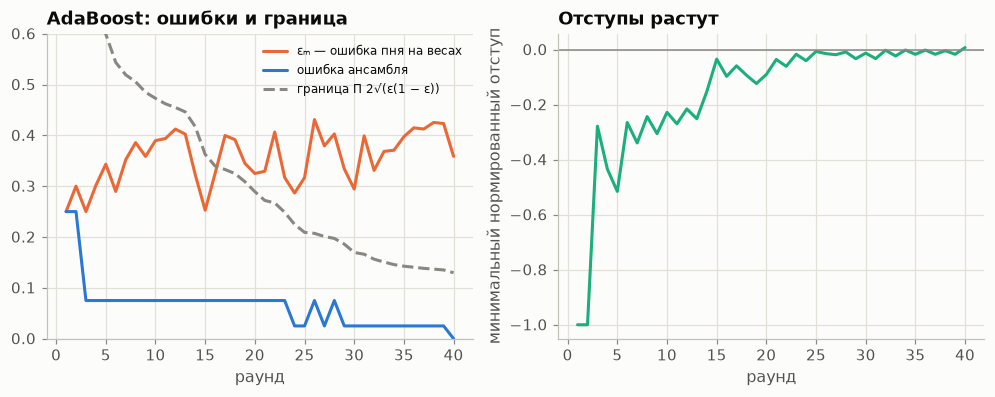

In [29]:
rng = Mulberry32(21)
xs = sorted(rng.uniform(0, 10) for _ in range(40))
ys = []
for xi in xs:
    yi = 1 if 3 < xi < 7 else 0
    ys.append(1 - yi if rng.random() < 0.08 else yi)
Xa, ya = np.array(xs)[:, None], np.array(ys)
ada = AdaBoost(n_estimators=40, max_depth=1).fit(Xa, ya)
s = np.where(ya == 1, 1, -1)
errs, margins, bound = [], [], []
for m in range(1, len(ada.trees_) + 1):
    Fm = ada.decision_function(Xa, m)
    errs.append(np.mean((Fm > 0) != (ya == 1)))
    margins.append((s * Fm / sum(ada.alphas_[:m])).min())
    bound.append(np.prod(2 * np.sqrt(np.array(ada.errors_[:m]) * (1 - np.array(ada.errors_[:m])))))
    w = np.exp(-s * Fm)
    assert np.allclose(w / w.sum(), ada.weights_[m])
print("веса AdaBoost = exp(−отступ)/Z на всех раундах — проверено")
print("ошибка ансамбля по раундам 1, 3, 23, 24, 40:", [errs[k] for k in (0, 2, 22, 23, 39)])
assert errs[2] == errs[22] == 0.075 and errs[-1] == 0 and margins[-1] > 0

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
r = np.arange(1, len(errs) + 1)
a1.plot(r, ada.errors_, color=ORANGE, label="εₘ — ошибка пня на весах")
a1.plot(r, errs, color=BLUE, lw=2, label="ошибка ансамбля")
a1.plot(r, bound, color=MUTED, ls="--", label="граница Π 2√(ε(1 − ε))")
a1.set(xlabel="раунд", ylim=(0, 0.6), title="AdaBoost: ошибки и граница")
a1.legend(fontsize=8)
a2.plot(r, margins, color=AQUA, lw=2)
a2.axhline(0, color=MUTED, lw=1)
a2.set(xlabel="раунд", ylabel="минимальный нормированный отступ", title="Отступы растут")
plt.show()

### Аукционы: эквивалентность доходов и резервная цена Майерсона

In [30]:
def revenue_sim(n, r, T=200000, seed=0):
    rng = np.random.default_rng(seed)   # здесь сравнение с веб-версией не нужно — только средние
    V = np.sort(rng.random((T, n)), axis=1)[:, ::-1]
    beta = lambda x: np.where(x < r, 0, x - (x**n - r**n) / (n * np.maximum(x, 1e-12) ** (n - 1)))
    sold = V[:, 0] >= r
    second = np.where(sold, np.maximum(V[:, 1], r), 0).mean()
    first = np.where(sold, beta(V[:, 0]), 0).mean()
    return first, second


R_th = lambda n, r: (n - 1) / (n + 1) + r**n - 2 * n * r ** (n + 1) / (n + 1)
for n, r in [(2, 0), (3, 0), (3, 0.5), (5, 0.5)]:
    f1, f2 = revenue_sim(n, r)
    print(f"n = {n}, r = {r}: первая цена {f1:.4f}, вторая {f2:.4f}, теория {R_th(n, r):.4f}")
    assert abs(f1 - R_th(n, r)) < 0.005 and abs(f2 - R_th(n, r)) < 0.005
rs = np.linspace(0, 1, 1001)
print("оптимальный резерв при n = 3:", rs[np.argmax(R_th(3, rs))])

n = 2, r = 0: первая цена 0.3333, вторая 0.3333, теория 0.3333
n = 3, r = 0: первая цена 0.5001, вторая 0.5001, теория 0.5000
n = 3, r = 0.5: первая цена 0.5315, вторая 0.5314, теория 0.5312
n = 5, r = 0.5: первая цена 0.6720, вторая 0.6723, теория 0.6719


оптимальный резерв при n = 3: 0.5


### Стратегическая классификация (игра Штакельберга)

θ = 0.5: до реакции 1.000, после 0.868; лучший θ = 0.65 → 1.000


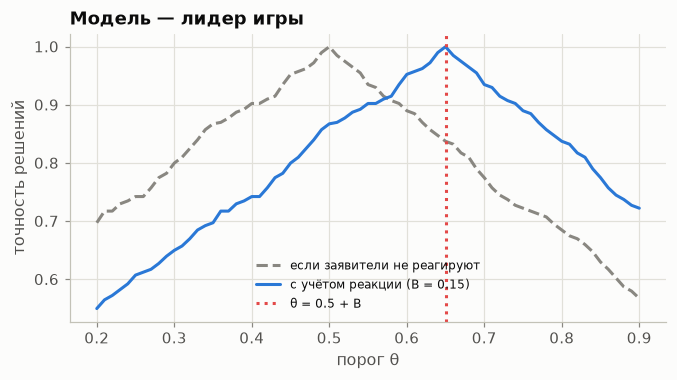

In [31]:
rng = Mulberry32(42)
qual = np.array([rng.random() for _ in range(400)])
acc = lambda th, B: np.mean((qual >= th - B) == (qual >= 0.5))
thetas = np.round(np.arange(0.2, 0.9001, 0.01), 2)
B = 0.15
best = max(thetas, key=lambda t: acc(t, B))
print(f"θ = 0.5: до реакции {acc(0.5, 0):.3f}, после {acc(0.5, B):.3f}; лучший θ = {best} → {acc(best, B):.3f}")
assert best == 0.65 and acc(best, B) == 1.0

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(thetas, [acc(t, 0) for t in thetas], color=MUTED, ls="--", label="если заявители не реагируют")
ax.plot(thetas, [acc(t, B) for t in thetas], color=BLUE, lw=2, label="с учётом реакции (B = 0.15)")
ax.axvline(0.5 + B, color=RED, ls=":", label="θ = 0.5 + B")
ax.set(xlabel="порог θ", ylabel="точность решений", title="Модель — лидер игры")
ax.legend(fontsize=8)
plt.show()

## Упражнения

Условия — в `exercises/tasks.md`, решения — `exercises/solutions.py`.